## 04 gradient-boosted trees

This replaces the lookup based approach with a gradient boosted tree search.

**Per-fragment features**
* ion type, fragment number, relative position, peptide length, charge
* the two residues immediately flanking the cleavage (N- and C-side), encoded
* counts of basic / acidic / proline residues on each side of the cleavage
* global basic/acidic counts, peptide mass
* modification flags around the cleavage

**Methodology** grouped 5-fold by peptide, scored with
masked spectral angle and Pearson, compared against the lookup approach
score saved in `approach1_score.npy`.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupKFold
import lightgbm as lgb

import common as c

RANDOM_STATE = 42

In [10]:
spectra = pd.read_parquet("spectra_with_charge.parquet")
N = 80_000
spectra = spectra.sample(min(N, len(spectra)), random_state=RANDOM_STATE).reset_index(drop=True)
print("spectra used:", len(spectra))

Y = np.stack([
    c.ions_to_vector(i, v, normalize=True)
    for i, v in zip(spectra["matched_ions"], spectra["intensities_raw"])
])
M = np.stack([c.valid_slot_mask(s) for s in spectra["peptide_sequence"]])
groups = spectra["peptide_sequence"].values
charge = spectra["precursor_charge"].values

tokens_list = [c.parse_peptide(s) for s in spectra["peptide_sequence"]]

spectra used: 80000


### feature construction

A `b{n}` ion cuts the peptide after residue `n` (N-terminal fragment)
A `y{n}` ion cuts before the last `n` residues. 
We encode the residues on each side of that bond plus local and global composition.

In [ ]:
# Residue -> to token
RES_TO_ID = {r: i + 1 for i, r in enumerate(c.AMINO_ACIDS)}

def res_id(tok):
    if tok is None:
        return 0
    return RES_TO_ID.get(c.strip_mods(tok), 0)

def is_mod(tok):
    return 0 if tok is None else int("[UNIMOD:" in tok)

BASIC = set("KRH"); ACID = set("DE")

def build_fragment_rows(idx_subset):
    feats, targets, spec_ids, slots = [], [], [], []
    for i in idx_subset:
        toks = tokens_list[i]
        L = len(toks)
        bare = [c.strip_mods(t) for t in toks]
        z = charge[i]
        n_basic = sum(a in BASIC for a in bare)
        n_acid = sum(a in ACID for a in bare)
        mass = sum(c.AA_MONO_MASS[a] for a in bare) + 18.01056 + \
               sum(c.MOD_MASS[t] for t in toks if t in c.MOD_MASS)
        for slot in np.where(M[i])[0]:
            ion_type, number = c.slot_to_fragment(int(slot))
            # Cleavage site: bond after position `cut` (1-based) counted from N-term.
            cut = number if ion_type == "b" else L - number
            left = toks[cut - 1] if 1 <= cut <= L else None      # residue N-side of bond
            right = toks[cut] if 0 <= cut < L else None          # residue C-side of bond
            n_left_basic = sum(a in BASIC for a in bare[:cut])
            n_right_basic = sum(a in BASIC for a in bare[cut:])
            feats.append([
                0 if ion_type == "b" else 1,
                number,
                number / L,
                L,
                z,
                res_id(left),
                res_id(right),
                is_mod(left),
                is_mod(right),
                n_basic,
                n_acid,
                n_left_basic,
                n_right_basic,
                int(left is not None and c.strip_mods(left) in ACID),
                int(right is not None and c.strip_mods(right) == "P"),
                mass,
                mass / L,
            ])
            targets.append(Y[i, slot])
            spec_ids.append(i)
            slots.append(int(slot))
    return (np.asarray(feats, dtype=np.float32),
            np.asarray(targets, dtype=np.float32),
            np.asarray(spec_ids), np.asarray(slots))

FEATURE_NAMES = [
    "ion", "number", "relpos", "L", "charge", "res_left", "res_right",
    "mod_left", "mod_right", "n_basic", "n_acid", "n_left_basic",
    "n_right_basic", "left_acidic", "right_proline", "mass", "mass_per_len",
]
CATEGORICAL = ["ion", "charge", "res_left", "res_right"]

## Grouped 5-fold evaluation

In [5]:
def reconstruct(spec_ids, slots, preds, n_spec):
    P = np.zeros((n_spec, c.VECTOR_DIM))
    P[spec_ids, slots] = np.clip(preds, 0, 1)
    return P

def lgb_params(**over):
    p = dict(
        objective="regression",
        n_estimators=400,
        learning_rate=0.05,
        num_leaves=63,
        min_child_samples=50,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=-1,
    )
    p.update(over)
    return p

gkf = GroupKFold(n_splits=5)
fold_scores = []
cat_idx = [FEATURE_NAMES.index(x) for x in CATEGORICAL]

for fold, (tr, te) in enumerate(gkf.split(np.arange(len(spectra)), groups=groups)):
    Xtr, ytr, _, _ = build_fragment_rows(tr)
    Xte, yte, sid_te, slot_te = build_fragment_rows(te)
    model = lgb.LGBMRegressor(**lgb_params())
    model.fit(Xtr, ytr, categorical_feature=cat_idx)
    pred = model.predict(Xte)
    P = reconstruct(sid_te, slot_te, pred, len(spectra))
    res = c.evaluate_vectors(Y[te], P[te], M[te])
    fold_scores.append(res)
    print(f"fold {fold}: SA={res['spectral_angle']:.4f} Pearson={res['pearson']:.4f}")

sa = np.array([f["spectral_angle"] for f in fold_scores])
pe = np.array([f["pearson"] for f in fold_scores])
print(f"\nApproach 2  SA = {sa.mean():.4f} +/- {sa.std():.4f}"
      f" | Pearson = {pe.mean():.4f} +/- {pe.std():.4f}")

/home/z0059nvp/dev/sommer/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


fold 0: SA=0.6579 Pearson=0.7772


/home/z0059nvp/dev/sommer/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


fold 1: SA=0.6601 Pearson=0.7797


/home/z0059nvp/dev/sommer/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


fold 2: SA=0.6585 Pearson=0.7782


/home/z0059nvp/dev/sommer/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


fold 3: SA=0.6598 Pearson=0.7799


/home/z0059nvp/dev/sommer/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


fold 4: SA=0.6592 Pearson=0.7788

Approach 2  SA = 0.6591 +/- 0.0008 | Pearson = 0.7787 +/- 0.0010


## Hyper-parameter optimisation

Search over three LightGBM hyperparameters (tree size, learning
rate, regularisation), scored with grouped 3-fold CV on the same data. Each
configuration is compared on mean spectral angle.

In [6]:
from itertools import product

#"""
grid = list(product(
    [31, 63, 127],      # num_leaves
    [0.03, 0.05],       # learning_rate
    [400, 700],         # n_estimators
))
"""
leaves= 31 lr=0.03 n_est=400  SA=0.6426
leaves= 31 lr=0.03 n_est=700  SA=0.6502
leaves= 31 lr=0.05 n_est=400  SA=0.6494
leaves= 31 lr=0.05 n_est=700  SA=0.6565

leaves= 63 lr=0.03 n_est=400  SA=0.6541
leaves= 63 lr=0.03 n_est=700  SA=0.6594
leaves= 63 lr=0.05 n_est=400  SA=0.6589
leaves= 63 lr=0.05 n_est=700  SA=0.6636

#this run took 312 mins, then i aborted
"""

# grid = list(product([63], [0.05], [700]))

gkf3 = GroupKFold(n_splits=3)
splits = list(gkf3.split(np.arange(len(spectra)), groups=groups))
# Build features once per fold (expensive part).
prepared = []
for tr, te in splits:
    prepared.append((build_fragment_rows(tr), build_fragment_rows(te), te))

search_rows = []
for num_leaves, lr, n_est in grid:
    sas = []
    for (Xtr, ytr, _, _), (Xte, yte, sid_te, slot_te), te in prepared:
        m = lgb.LGBMRegressor(**lgb_params(num_leaves=num_leaves,
                                           learning_rate=lr, n_estimators=n_est))
        m.fit(Xtr, ytr, categorical_feature=cat_idx)
        P = reconstruct(sid_te, slot_te, m.predict(Xte), len(spectra))
        sas.append(c.evaluate_vectors(Y[te], P[te], M[te])["spectral_angle"])
    search_rows.append((num_leaves, lr, n_est, float(np.mean(sas))))
    print(f"leaves={num_leaves:3d} lr={lr} n_est={n_est:3d}  SA={np.mean(sas):.4f}")

search = pd.DataFrame(search_rows, columns=["num_leaves", "lr", "n_est", "SA"])
best = search.sort_values("SA", ascending=False).iloc[0]
print("\nbest config:\n", best)

/home/z0059nvp/dev/sommer/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/z0059nvp/dev/sommer/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/z0059nvp/dev/sommer/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


leaves= 31 lr=0.03 n_est=400  SA=0.6426


/home/z0059nvp/dev/sommer/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/z0059nvp/dev/sommer/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/z0059nvp/dev/sommer/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


leaves= 31 lr=0.03 n_est=700  SA=0.6502


/home/z0059nvp/dev/sommer/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/z0059nvp/dev/sommer/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/z0059nvp/dev/sommer/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


...

leaves=127 lr=0.03 n_est=700  SA=0.6655


/home/z0059nvp/dev/sommer/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/z0059nvp/dev/sommer/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/z0059nvp/dev/sommer/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


leaves=127 lr=0.05 n_est=400  SA=0.6652


/home/z0059nvp/dev/sommer/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/z0059nvp/dev/sommer/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/z0059nvp/dev/sommer/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


leaves=127 lr=0.05 n_est=700  SA=0.6674

best config:
 num_leaves    127.000000
lr              0.050000
n_est         700.000000
SA              0.667369
Name: 11, dtype: float64


## Fit the tuned model, compare to statistical

In [7]:
best_params = lgb_params(num_leaves=int(best.num_leaves),
                         learning_rate=float(best.lr),
                         n_estimators=int(best.n_est))

Xall, yall, _, _ = build_fragment_rows(np.arange(len(spectra)))
final_model = lgb.LGBMRegressor(**best_params)
final_model.fit(Xall, yall, categorical_feature=cat_idx)

approach2_sa = max(sa.mean(), best.SA)
approach1_sa = float(np.load("approach1_score.npy")[0])
print(f"Approach 1 SA: {approach1_sa:.4f}")
print(f"Approach 2 SA: {approach2_sa:.4f}")
print(f"improvement : {approach2_sa - approach1_sa:+.4f}")
np.save("approach2_score.npy", np.array([approach2_sa]))

Approach 1 SA: 0.5247
Approach 2 SA: 0.6674
improvement : +0.1427


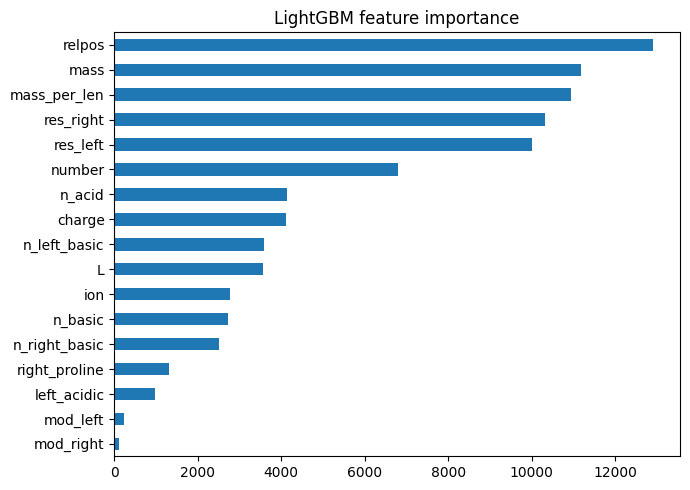

In [ ]:
# Look at this graph!
imp = pd.Series(final_model.feature_importances_, index=FEATURE_NAMES).sort_values()
fig, ax = plt.subplots(figsize=(7, 5))
imp.plot.barh(ax=ax); ax.set_title("LightGBM feature importance")
plt.tight_layout(); plt.show()

In [9]:
def predict_intensities_approach2(peptide, precursor_charge):
    toks = c.parse_peptide(peptide)
    L = len(toks)
    bare = [c.strip_mods(t) for t in toks]
    z = precursor_charge
    n_basic = sum(a in BASIC for a in bare)
    n_acid = sum(a in ACID for a in bare)
    mass = sum(c.AA_MONO_MASS[a] for a in bare) + 18.01056 + \
           sum(c.MOD_MASS[t] for t in toks if t in c.MOD_MASS)
    mask = c.valid_slot_mask(peptide)
    feats, slots = [], []
    for slot in np.where(mask)[0]:
        ion_type, number = c.slot_to_fragment(int(slot))
        cut = number if ion_type == "b" else L - number
        left = toks[cut - 1] if 1 <= cut <= L else None
        right = toks[cut] if 0 <= cut < L else None
        feats.append([
            0 if ion_type == "b" else 1, number, number / L, L, z,
            res_id(left), res_id(right), is_mod(left), is_mod(right),
            n_basic, n_acid,
            sum(a in BASIC for a in bare[:cut]),
            sum(a in BASIC for a in bare[cut:]),
            int(left is not None and c.strip_mods(left) in ACID),
            int(right is not None and c.strip_mods(right) == "P"),
            mass, mass / L,
        ])
        slots.append(int(slot))
    pred = np.clip(final_model.predict(np.asarray(feats, dtype=np.float32)), 0, 1)
    vec = np.zeros(c.VECTOR_DIM); vec[slots] = pred
    return c.prediction_table(peptide, vec)

print(predict_intensities_approach2("LTQETNRV", 4).to_string(index=False))

final_model.booster_.save_model("le-final.model")
import joblib

# Save the model
joblib.dump(final_model, 'le_final-joblib.pkl')

Fragment ion  Fragment Number  Intensity
           B                1   0.017807
           B                2   0.240995
           B                3   0.134178
           B                4   0.136105
           B                5   0.091946
           B                6   0.085609
           B                7   0.106700
           Y                1   0.043666
           Y                2   0.162699
           Y                3   0.160192
           Y                4   0.211472
           Y                5   0.268263
           Y                6   0.510604
           Y                7   0.181157


/home/z0059nvp/dev/sommer/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


['le_final-joblib.pkl']